# Visualizzare il Rendimento agli Esami degli Studenti con Superfici 3D e Grafici a Dispersione (PROC G3D)

## Sintesi Esecutiva

Questo notebook usa **PROC G3D** per visualizzare come due fattori di
intervento didattico plasmano congiuntamente gli esiti degli studenti in
un contesto di analytics educativo. Una griglia fattoriale completa
guida una **superficie** di risposta continua dei punteggi d'esame
previsti sulle ore settimanali di studio (da 0 a 20) e sul GPA
precedente (da 0 a 4), e una coorte sintetica di 100 studenti viene
resa come pannelli di **dispersione 3D** suddivisi per fascia di
rendimento.

La superficie adattata sale da un punteggio previsto vicino a 26 a zero
ore di studio verso un tetto vicino a 99, appiattendosi quando le ore di
studio superano circa 10 — la cresta a rendimenti decrescenti che il
modello codifica. I pannelli degli studenti confermano lo schema a
livello individuale: i 20 studenti *Eccellenza* (ognuno con un punteggio
di 85 o superiore) si collocano nell'angolo con GPA alto e studio
maggiore, mentre i 33 studenti *ARischio* si concentrano nella regione a
basso impegno e basso GPA. Una vista filtrata con WHERE su quell'angolo
isola 35 studenti per i quali modesti aumenti del tempo di studio
offrono i maggiori guadagni marginali.


## Fonti dei Dati

Tutti i dati sono generati inline con `call streaminit()` e `rand()` —
nessun file esterno o accesso di rete.

**`score_grid`** — griglia fattoriale completa che guida la superficie
di risposta (una riga per cella ore-di-studio x GPA-precedente, 99
righe).

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `study_hours` | Num | Ore settimanali di studio autonomo, da 0 a 20 a passi di 2 (asse X) |
| `prior_gpa` | Num | GPA del periodo precedente su scala 0–4, da 0 a 4 a passi di 0,5 (asse Y) |
| `pred_score` | Num | Punteggio d'esame finale modellato 0–100 da un modello di risposta saturante (asse Z) |

**`students`** — coorte sintetica di singoli studenti per la
dispersione (100 righe).

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `student_id` | Num | Identificativo sequenziale dello studente |
| `study_hours` | Num | Ore settimanali di studio osservate (asse X) |
| `prior_gpa` | Num | GPA del periodo precedente osservato (asse Y) |
| `exam_score` | Num | Punteggio d'esame finale osservato 0–100 (asse Z) |
| `cohort` | Char | Coorte di iscrizione, `Autunno` o `Primavera` |
| `band` | Char | Fascia di rendimento: `Eccellenza` (≥85), `Promosso` (65–84), `ARischio` (<65) |

La griglia è deliberatamente dimensionata a 99 celle così da coprire
l'intero intervallo 0–20 di ore di studio e 0–4 di GPA restando entro il
limite di 100 osservazioni di questo ambiente; un reticolo 11 x 9
mantiene la superficie liscia senza troncare nessuno dei due assi.


# Visualizzare il Rendimento agli Esami degli Studenti con PROC G3D

I ricercatori in ambito educativo spesso vogliono capire come due
fattori modificabili guidano congiuntamente un esito. Qui ci chiediamo:
*come si combinano le ore settimanali di studio e il GPA precedente di
uno studente per plasmare il rendimento all'esame finale?*

Un grafico bidimensionale non può mostrare una superficie di
interazione. **PROC G3D** disegna veri grafici tridimensionali da
variabili in notazione `y*x=z`, dove X e Y coprono il piano orizzontale
e Z sale verticalmente. Usiamo due delle sue capacità:

- **PLOT** — una **superficie** di risposta continua su una griglia
  completa dei due predittori.
- **SCATTER** — singoli studenti tracciati come simboli 3D. Rendiamo
  un pannello per fascia di rendimento, ciascuno con il proprio colore
  e forma del marcatore, così le tre fasce di esito sono facili da
  confrontare.

Tutto quanto segue viene eseguito su dati sintetici generati inline,
quindi il notebook è completamente autonomo.


## Passo 1 — Generare la griglia della superficie di risposta

Un grafico di superficie G3D richiede una griglia ragionevolmente
completa: servono valori Z non mancanti per almeno metà delle celle
X-Y. Garantiamo una griglia *completa* annidando due cicli `DO` su
`study_hours` (da 0 a 20 a passi di 2) e `prior_gpa` (da 0 a 4 a passi
di 0,5) — un reticolo 11 x 9 di 99 celle che copre interamente entrambi
gli assi.

Il punteggio previsto segue un modello saturante plausibile: i
rendimenti dello studio diminuiscono alle ore elevate, il GPA
precedente contribuisce in modo pressoché lineare, e i due
interagiscono (uno studente forte converte il tempo di studio in punti
in modo più efficiente). Un piccolo rumore riproducibile da
`rand('NORMAL')` evita che la superficie appaia perfettamente
analitica. `call streaminit()` fissa il seme così la griglia è
riproducibile.


In [1]:
DATI score_grid;
   CHIAMARE streaminit(20260531);
   FARE study_hours = 0 FINO_A 20 PER 2;     /* 11 valori: intero intervallo 0-20 */
      FARE prior_gpa = 0 FINO_A 4 PER 0.5;   /* 9 valori  -> 99 celle della griglia */
         /* rendimento saturante rispetto alle ore di studio */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* rendimento pregresso e un termine di interazione */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         SE_COND pred_score > 100 ALLORA pred_score = 100;
         SE_COND pred_score < 0   ALLORA pred_score = 0;
         USCITA;
      FINE;
   FINE;
   MANTENERE study_hours prior_gpa pred_score;
ESEGUIRE;

PROCEDURA MEDIE DATI=score_grid n MIN mean MAX maxdec=1;
   ETICHETTA study_hours="Ore di Studio Settimanali" prior_gpa="GPA Precedente" pred_score="Punteggio Esame Previsto";
   VARIABILE study_hours prior_gpa pred_score;
ESEGUIRE;


                                                  The MEANS Procedure

 Variable     Label                            N     Minimum        Mean     Maximum
 -----------------------------------------------------------------------------------
 study_hours  Ore di Studio Settimanali       99         0.0        10.0        20.0
 prior_gpa    GPA Precedente                  99         0.0         2.0         4.0
 pred_score   Punteggio Esame Previsto        99        25.7        70.0        98.7
 -----------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 2 — Disegnare la superficie di risposta di base

Con una griglia completa a disposizione, la chiamata più semplice
disegna la superficie usando le impostazioni predefinite della
procedura. La sintassi `PLOT y*x=z` mappa `prior_gpa` sull'asse Y,
`study_hours` sull'asse X e il punteggio previsto sull'asse Z
verticale.

Etichettiamo gli assi con un'istruzione `LABEL` e impostiamo titoli e
una nota a piè di pagina con le istruzioni globali `TITLE`/`FOOTNOTE`
così il grafico si legge in modo chiaro.


                                    Superficie del Punteggio d'Esame Finale Previsto                                    
                              Effetto delle Ore Settimanali di Studio e del GPA Precedente                              

PROC G3D Output
Data: score_grid

Variables: Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Previsto

Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Previsto
-------------------------  --------------------------  ------------------------
                        0                           0             25.7031536911
                        0                         0.5             28.9516502743
                        0                           1             32.3400787822
                        0                         1.5             36.8265757618
                        0                           2             40.7806886968
                        0                         2.5               42.


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Superficie del Punteggio d'Esame Finale Previsto.
NOTE: Option TITLE2 changed to Effetto delle Ore Settimanali di Studio e del GPA Precedente.
NOTE: Option FOOTNOTE changed to Dati sintetici di analytics educativo .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


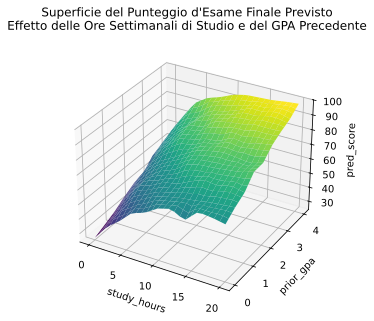

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITOLO "Superficie del Punteggio d'Esame Finale Previsto";
title2 'Effetto delle Ore Settimanali di Studio e del GPA Precedente';
footnote j=r 'Dati sintetici di analytics educativo ';

PROCEDURA g3d DATI=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         pred_score  = 'Punteggio Esame Previsto';
ESEGUIRE;
QUIT;


## Passo 3 — Rifinire la superficie con opzioni di visuale e assi

Alcune opzioni rendono la superficie molto più leggibile:

- **ROTATE=** e **TILT=** impostano l'angolo di visuale (gradi attorno
  all'asse Z, e inclinazione verso l'osservatore).
- **XYTYPE=2** disegna le linee della superficie parallele all'asse Y,
  enfatizzando come il punteggio salga con le ore di studio.
- **SIDE** aggiunge una parete laterale per un aspetto solido e
  scolpito.
- **GRID** aggiunge linee di riferimento in corrispondenza delle tacche
  principali.
- **ZMIN=/ZMAX=** e la famiglia **ZTICKNUM=** fissano l'asse del
  punteggio all'intero intervallo 0–100 così la superficie non è
  visivamente esagerata, mentre **XTICKNUM=/YTICKNUM=** controllano le
  tacche del piano di base.
- **NAME=** e **DESCRIPTION=** etichettano il grafico nel catalogo di
  output.


                              Superficie del Punteggio d'Esame Previsto (Vista Stilizzata)                              
                                         Ruotata, Inclinata e con Assi Scalati                                          

PROC G3D Output
Data: score_grid

Variables: Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Previsto

Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Previsto
-------------------------  --------------------------  ------------------------
                        0                           0             25.7031536911
                        0                         0.5             28.9516502743
                        0                           1             32.3400787822
                        0                         1.5             36.8265757618
                        0                           2             40.7806886968
                        0                         2.5               42.


NOTE: Option TITLE changed to Superficie del Punteggio d'Esame Previsto (Vista Stilizzata).
NOTE: Option TITLE2 changed to Ruotata, Inclinata e con Assi Scalati.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


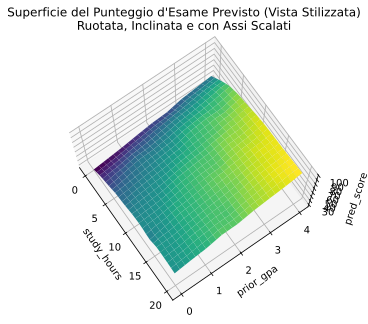

In [3]:
TITOLO "Superficie del Punteggio d'Esame Previsto (Vista Stilizzata)";
title2 'Ruotata, Inclinata e con Assi Scalati';

PROCEDURA g3d DATI=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Superficie di risposta del punteggio esame stilizzata";
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         pred_score  = 'Punteggio Esame Previsto';
ESEGUIRE;
QUIT;


## Passo 4 — Confrontare la superficie da diverse angolazioni

Poiché una superficie 3D può nascondere struttura dietro le proprie
creste, aiuta rendere la stessa superficie da più di una rotazione. Qui
eseguiamo tre passi PROC G3D che condividono un'inclinazione fissa ma
fanno avanzare l'angolo **ROTATE=** attraverso 30, 90 e 150 gradi, così
la cresta può essere ispezionata dal fronte, dal lato e da dietro.


                                                 Superficie di Risposta                                                 
                                           ROTATE = 30 con Inclinazione Fissa                                           

PROC G3D Output
Data: score_grid

Variables: Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Previsto

Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Previsto
-------------------------  --------------------------  ------------------------
                        0                           0             25.7031536911
                        0                         0.5             28.9516502743
                        0                           1             32.3400787822
                        0                         1.5             36.8265757618
                        0                           2             40.7806886968
                        0                         2.5               42.


NOTE: Option TITLE changed to Superficie di Risposta.
NOTE: Option TITLE2 changed to ROTATE = 30 con Inclinazione Fissa.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Superficie di Risposta.
NOTE: Option TITLE2 changed to ROTATE = 90 con Inclinazione Fissa.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Superficie di Risposta.
NOTE: Option TITLE2 changed to ROTATE = 150 con Inclinazione Fissa.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


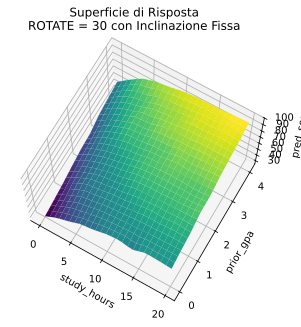

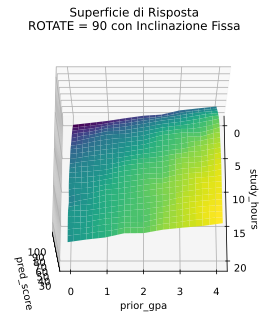

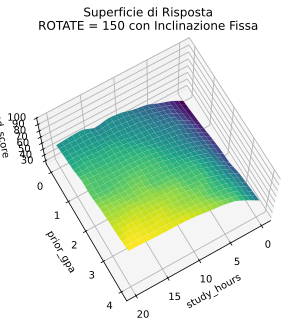

In [4]:
%macro angle(deg);
   TITOLO 'Superficie di Risposta';
   title2 "ROTATE = &deg con Inclinazione Fissa";
   PROCEDURA g3d DATI=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ETICHETTA study_hours = 'Ore di Studio Settimanali'
            prior_gpa   = 'GPA del Periodo Precedente'
            pred_score  = 'Punteggio Esame Previsto';
   ESEGUIRE;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Passo 5 — Generare una coorte sintetica di studenti

La superficie è un modello; gli studenti reali si disperdono attorno ad
essa. Ora simuliamo 100 singoli studenti tratti da due coorti di
iscrizione (`Autunno`, `Primavera`). Ogni studente ha ore di studio
osservate, un GPA precedente e un punteggio d'esame realizzato rumoroso
generato dalla stessa logica di risposta più una maggiore variazione
individuale.

Deriviamo quindi una **fascia** di rendimento dal punteggio d'esame:
`Eccellenza` (85 o superiore), `Promosso` (da 65 a 84) e `ARischio`
(sotto 65). La tabulazione incrociata PROC FREQ sottostante riporta come
le fasce si distribuiscono tra le due coorti. `rand('UNIFORM')` e
`rand('NORMAL')` forniscono la casualità; il seme la mantiene
riproducibile.


                                                 Superficie di Risposta                                                 
                                          ROTATE = 150 con Inclinazione Fissa                                           

                                                   The FREQ Procedure

                                     Cumulative
Fascia di Rendimento    Frequency    Frequency
--------------------------------------------------
ARischio                       33           33
Eccellenza                     20           53
Promosso                       47          100

Table of Coorte by Fascia di Rendimento

Coorte    |  ARischio |Eccellenza |  Promosso |      Total
----------+-----------+-----------+-----------+-----------
Autunno   |        15 |         6 |        20 |         41
----------+-----------+-----------+-----------+-----------
Primavera |        18 |        14 |        27 |         59
----------+-----------+-----------+-----------+-----------
Tot


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


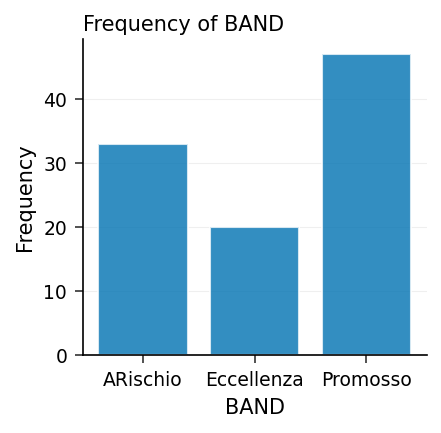

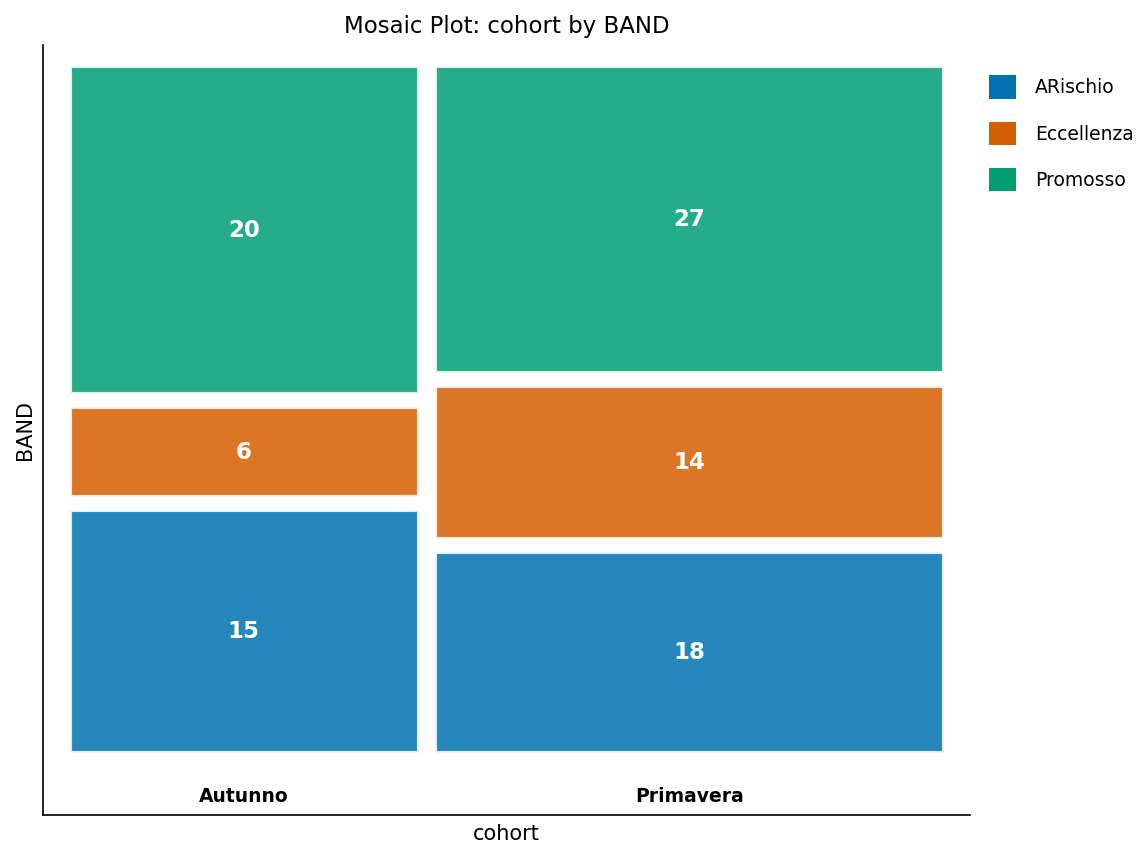

In [5]:
DATI students;
   CHIAMARE streaminit(99001);
   LUNGHEZZA cohort $10 BAND $12;
   FARE student_id = 1 FINO_A 100;
      SE_COND rand('UNIFORM') < 0.5 ALLORA cohort = 'Autunno';
      ALTRIMENTI cohort = 'Primavera';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      SE_COND exam_score > 100 ALLORA exam_score = 100;
      SE_COND exam_score < 0   ALLORA exam_score = 0;

      SE_COND exam_score >= 85 ALLORA BAND = 'Eccellenza';
      ALTRIMENTI SE_COND exam_score >= 65 ALLORA BAND = 'Promosso';
      ALTRIMENTI BAND = 'ARischio';

      USCITA;
   FINE;
   MANTENERE student_id cohort study_hours prior_gpa exam_score BAND;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=students;
   ETICHETTA BAND="Fascia di Rendimento" cohort="Coorte";
   TABLES BAND cohort*BAND / nocol nopercent;
ESEGUIRE;


## Passo 6 — Tracciare gli studenti come pannelli di dispersione 3D per fascia di rendimento

L'istruzione **SCATTER** posiziona ogni studente come simbolo 3D. Per
rendere le tre fasce di rendimento facili da leggere, disegniamo un
pannello per fascia, ciascuno filtrato con **WHERE** e con il proprio
**COLOR=** e **SHAPE=** letterali: rombi verdi (`SHAPE=diamond`) per
*Eccellenza*, marcatori blu (`SHAPE=club`) per *Promosso*, e marcatori
rossi (`SHAPE=spade`) per *ARischio*. **SIZE=** ingrandisce i
marcatori, **GRID** aggiunge linee di riferimento del piano di base,
**NONEEDLE** rimuove le linee di caduta verticali, e **ZMIN=/ZMAX=**
mantengono ogni pannello sullo stesso asse del punteggio 0–100 così le
tre viste sono direttamente confrontabili.

Ogni fascia ottiene il proprio passo PROC G3D così il suo filtro WHERE
si applica in modo pulito e lo stile del marcatore è inequivocabile.


                                                  Studenti Eccellenza                                                   
                                             Punteggio Esame 85 e Superiore                                             

PROC G3D Output
Data: students

Variables: student_id, cohort, Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Finale, BAND

student_id      cohort  Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Finale        BAND
----------  ----------  -------------------------  --------------------------  ----------------------  ----------
         2   Primavera              19.2134883194                2.6467742616           90.3663886999  Eccellenza
         5   Primavera              15.5520919174                2.7102003827           94.9419468332  Eccellenza
        10   Primavera              14.2302640951                3.8791496428                     100  Eccellenza
        17   Primavera              13.


NOTE: Option FOOTNOTE changed to Da una coorte di 100 studenti sintetici .
NOTE: Option TITLE changed to Studenti Eccellenza.
NOTE: Option TITLE2 changed to Punteggio Esame 85 e Superiore.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Studenti Promosso.
NOTE: Option TITLE2 changed to Punteggio Esame da 65 a 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Studenti a Rischio.
NOTE: Option TITLE2 changed to Punteggio Esame Sotto 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


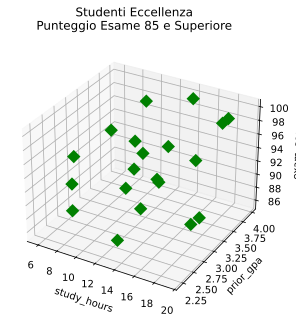

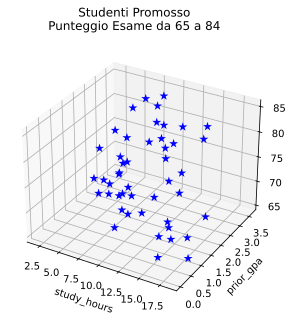

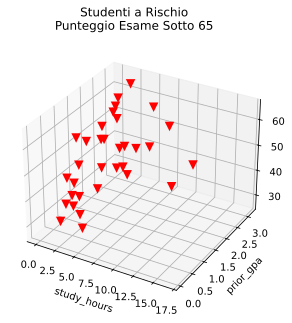

In [6]:
footnote j=r 'Da una coorte di 100 studenti sintetici ';

/* Eccellenza (exam_score >= 85): rombi verdi */
TITOLO 'Studenti Eccellenza';
title2 'Punteggio Esame 85 e Superiore';
PROCEDURA g3d DATI=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Studenti Eccellenza";
   DOVE BAND = 'Eccellenza';
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         exam_score  = 'Punteggio Esame Finale';
ESEGUIRE;
QUIT;

/* Promosso (65 <= exam_score < 85): fiori blu */
TITOLO 'Studenti Promosso';
title2 'Punteggio Esame da 65 a 84';
PROCEDURA g3d DATI=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Studenti Promosso";
   DOVE BAND = 'Promosso';
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         exam_score  = 'Punteggio Esame Finale';
ESEGUIRE;
QUIT;

/* ARischio (exam_score < 65): picche rosse */
TITOLO 'Studenti a Rischio';
title2 'Punteggio Esame Sotto 65';
PROCEDURA g3d DATI=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Studenti a rischio";
   DOVE BAND = 'ARischio';
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         exam_score  = 'Punteggio Esame Finale';
ESEGUIRE;
QUIT;


## Passo 7 — Grafici di dispersione separati per coorte di iscrizione (gruppo BY)

I responsabili di programma spesso necessitano della stessa vista
suddivisa per coorte. L'istruzione **BY** produce una dispersione per
coorte. G3D richiede che i dati del gruppo BY siano ordinati, quindi
ordiniamo prima con PROC SORT. Ogni coorte ottiene quindi la propria
dispersione 3D etichettata su un asse del punteggio 0–100 condiviso,
rendendo facile confrontare fianco a fianco le distribuzioni Autunno e
Primavera.


                                          Esiti Esame per Coorte di Iscrizione                                          
                                   Una Dispersione 3D per Coorte (Autunno, Primavera)                                   

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Finale, BAND

student_id      cohort  Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Finale        BAND
----------  ----------  -------------------------  --------------------------  ----------------------  ----------
        52     Autunno              15.2586640362                0.4602308374           55.5186804916    ARischio
        13     Autunno               5.8493366471                1.8449001873           70.6084324429    Promosso
        15     Autunno               5.5070892672                1.4478111608           70.0069314398    Promosso
        22     Autunno          


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Esiti Esame per Coorte di Iscrizione.
NOTE: Option TITLE2 changed to Una Dispersione 3D per Coorte (Autunno, Primavera).
NOTE: Option FOOTNOTE changed to Un pannello per coorte .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


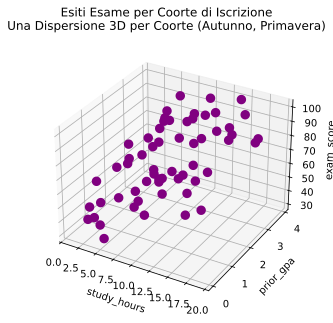

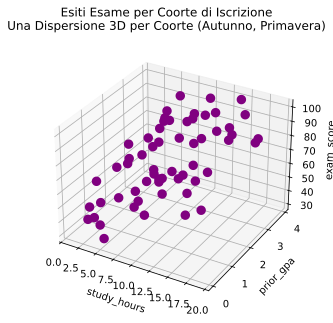

In [7]:
PROCEDURA ORDINARE DATI=students out=students_sorted;
   PER cohort;
ESEGUIRE;

TITOLO 'Esiti Esame per Coorte di Iscrizione';
title2 'Una Dispersione 3D per Coorte (Autunno, Primavera)';
footnote j=r 'Un pannello per coorte ';

PROCEDURA g3d DATI=students_sorted;
   PER cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         exam_score  = 'Punteggio Esame Finale';
ESEGUIRE;
QUIT;


## Passo 8 — Concentrarsi sulla regione a rischio con WHERE

Per la pianificazione degli interventi, la vista più attuabile è
l'angolo in basso a sinistra della superficie: studenti con tempo di
studio modesto (8 ore o meno) e GPA precedente più basso (2,5 o meno).
L'istruzione **WHERE** sottoinsiema la dispersione a quella regione
prima del tracciamento. Il listato mostra che questo angolo contiene 35
dei 100 studenti — 22 dei quali già *ARischio* — così i consulenti
possono vedere esattamente quali studenti in difficoltà si trovano più
lontano dalle aspettative.


                            Focus di Intervento: Studenti con Minore Impegno e GPA Più Basso                            
                                          study_hours <= 8 e prior_gpa <= 2.5                                           

PROC G3D Output
Data: students

Variables: student_id, cohort, Ore di Studio Settimanali, GPA del Periodo Precedente, Punteggio Esame Finale, BAND

student_id      cohort  Ore di Studio Settimanali  GPA del Periodo Precedente  Punteggio Esame Finale        BAND
----------  ----------  -------------------------  --------------------------  ----------------------  ----------
         1     Autunno               4.9780700766                 1.072086769            59.409228777    ARischio
         7   Primavera               7.9015823058                1.6623636789           66.9055021729    Promosso
         9   Primavera               2.5008494545                0.3621033759           48.1183184446    ARischio
        11   Primavera               7.


NOTE: Option TITLE changed to Focus di Intervento: Studenti con Minore Impegno e GPA Più Basso.
NOTE: Option TITLE2 changed to study_hours <= 8 e prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Gli aghi collegano ogni marcatore al piano ore-di-studio x GPA .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


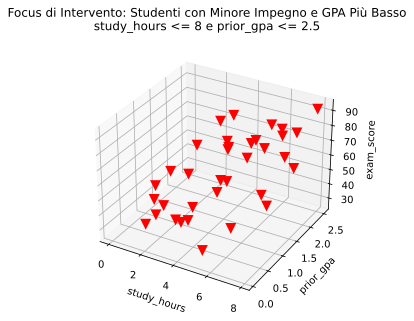

In [8]:
TITOLO 'Focus di Intervento: Studenti con Minore Impegno e GPA Più Basso';
title2 'study_hours <= 8 e prior_gpa <= 2.5';
footnote j=r 'Gli aghi collegano ogni marcatore al piano ore-di-studio x GPA ';

PROCEDURA g3d DATI=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   DOVE study_hours <= 8 E_LOG prior_gpa <= 2.5;
   ETICHETTA study_hours = 'Ore di Studio Settimanali'
         prior_gpa   = 'GPA del Periodo Precedente'
         exam_score  = 'Punteggio Esame Finale';
ESEGUIRE;
QUIT;


## Interpretare i Risultati

La **superficie di risposta** (Passi 2–4) mostra una chiara cresta
saturante. Sull'intera griglia di 99 celle il punteggio previsto va da
circa 26 (zero ore di studio, zero GPA) fino a circa 99 (l'angolo con
ore e GPA elevati), con una media sull'intera griglia vicina a 70.
Leggendo lungo l'asse delle ore di studio, i punteggi salgono
ripidamente da 0 fino a circa 10 ore e poi si appiattiscono quando le
ore aggiuntive producono rendimenti decrescenti; leggendo lungo l'asse
del GPA, il rendimento precedente sposta l'intera superficie verso
l'alto. Il termine di interazione rende il guadagno delle ore di
studio un po' più ripido per gli studenti più forti, motivo per cui la
superficie si inclina verso l'angolo lontano anziché salire come un
piano piatto.

I **pannelli degli studenti** (Passi 6–7) confermano che il modello
vale anche a livello individuale. La coorte di 100 si divide in 20
studenti *Eccellenza*, 47 *Promosso* e 33 *ARischio*. Nei pannelli per
fascia, i 20 rombi verdi *Eccellenza* — ognuno con un punteggio di 85 o
superiore — si collocano a un GPA precedente di 2,2 o superiore e ad
almeno circa 6 ore settimanali di studio, raggruppati nell'angolo in
alto a destra del piano di base. I 33 marcatori rossi *ARischio* si
concentrano nella regione a basso impegno e basso GPA, esattamente la
valle della superficie. La suddivisione per coorte mostra che le
distribuzioni Autunno (41 studenti) e Primavera (59 studenti) sono
ampiamente simili, suggerendo che gli esiti sono guidati dai due
fattori piuttosto che dai tempi di iscrizione.

La **vista filtrata con WHERE** (Passo 8) isola la popolazione per
l'intervento: i 35 studenti con 8 o meno ore di studio e un GPA di 2,5
o meno. Ventidue sono già *ARischio* e solo uno raggiunge *Eccellenza*.
All'interno di questo angolo i punteggi realizzati salgono ancora
visibilmente con le ore di studio — un argomento concreto e visivo che
modesti aumenti del tempo di studio strutturato offrono i maggiori
guadagni marginali esattamente dove sono più necessari.

Nel complesso, PROC G3D trasforma un modello di interazione a due
fattori in un quadro intuitivo e pronto per la decisione per un
programma educativo: dove si trova il tetto del punteggio, chi è al di
sotto di esso, e dove lo sforzo di coaching pagherà di più.

> **Nota implementativa.** SAS/GRAPH consente anche a una singola
> istruzione SCATTER di colorare e dare forma a ogni marcatore da
> variabili per osservazione (`COLOR=<charvar>`, `SHAPE=<charvar>`).
> Questa forma per osservazione non è ancora resa in questo motore,
> quindi questo notebook disegna invece un pannello a colore letterale
> per fascia — una presentazione equivalente e pienamente funzionante.
> La lacuna è tracciata dal test di regressione archiviato
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
